# Training

In [1]:
from bot import Plankton, ExportPlankton
from dataset import ChessPlaying

import torch
from tqdm import tqdm
from torch.optim import Adam
from torch.nn import functional as F

from matplotlib import pyplot as plt

In [2]:
env = ChessPlaying(Plankton())
env()

1 142 0 False True True
2 263 0 False True True
3 329 0 False True True
4 413 0 False True True
5 568 0 False True True
6 707 0 False True True
7 836 0 False True True
8 1031 0 False False True
9 1124 0 False True True
10 1277 0 False True True
11 1414 0 False True True
12 1414 144 True False False


([tensor([[0.0291, 0.0415, 0.0564, 0.0491, 0.0867, 0.2314, 0.1012, 0.4046],
          [0.0919, 0.0946, 0.3066, 0.0189, 0.1378, 0.0866, 0.2440, 0.0195],
          [0.4323, 0.2080, 0.0560, 0.1583, 0.0370, 0.0737, 0.0124, 0.0224],
          [0.1733, 0.0804, 0.0900, 0.0640, 0.0594, 0.0896, 0.0670, 0.3763]],
         dtype=torch.float64, grad_fn=<StackBackward0>),
  tensor([[0.0299, 0.0469, 0.0528, 0.0602, 0.1179, 0.2456, 0.1210, 0.3258],
          [0.1030, 0.0816, 0.2762, 0.0230, 0.1058, 0.1173, 0.2522, 0.0410],
          [0.3160, 0.1984, 0.0707, 0.2449, 0.0520, 0.0777, 0.0193, 0.0211],
          [0.2679, 0.0644, 0.0798, 0.0701, 0.0601, 0.0591, 0.1100, 0.2885]],
         dtype=torch.float64, grad_fn=<StackBackward0>),
  tensor([[0.0508, 0.0412, 0.0644, 0.0781, 0.0832, 0.2723, 0.0880, 0.3220],
          [0.0724, 0.1187, 0.3449, 0.0272, 0.1353, 0.1080, 0.1601, 0.0335],
          [0.4027, 0.1866, 0.0461, 0.2060, 0.0403, 0.0774, 0.0162, 0.0245],
          [0.1808, 0.0836, 0.0778, 0.0777, 0.054

In [ ]:
num_param = lambda m: sum(p.numel() for p in m.parameters())

def loss_func():...#log move

def train(env, opt, game=1):
    hist_loss = []

    for _ in tqdm(range(game), "Games"):
        white, black = env()
        loss = loss_func(white, black)
        
        loss.backward()
        opt.step()
        opt.zero_grad()
        hist_loss.append(loss.item())

    return hist_loss

@torch.no_grad()
def test(model): pass

In [ ]:
plankton = Plankton()
env = ChessPlaying(plankton, 128)
opt = Adam(
    plankton.parameters(),
    lr=1e-4,
)

print("Numerical parameters in the model:", num_param(plankton))
print(plankton)

Numerical parameters in the model: 7514
Plankton(
  (emb): Embedding(13, 2)
  (brain): Sequential(
    (0): Linear(in_features=69, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=64, bias=True)
    (5): ReLU()
  )
  (from_x): Sequential(
    (0): Linear(in_features=64, out_features=8, bias=True)
    (1): LogSoftmax(dim=-1)
  )
  (from_y): Sequential(
    (0): Linear(in_features=64, out_features=8, bias=True)
    (1): LogSoftmax(dim=-1)
  )
  (to_x): Sequential(
    (0): Linear(in_features=64, out_features=8, bias=True)
    (1): LogSoftmax(dim=-1)
  )
  (to_y): Sequential(
    (0): Linear(in_features=64, out_features=8, bias=True)
    (1): LogSoftmax(dim=-1)
  )
)


Epoch: 100%|██████████| 100/100 [44:45<00:00, 26.85s/it]

End loss: 0.027511608911041863


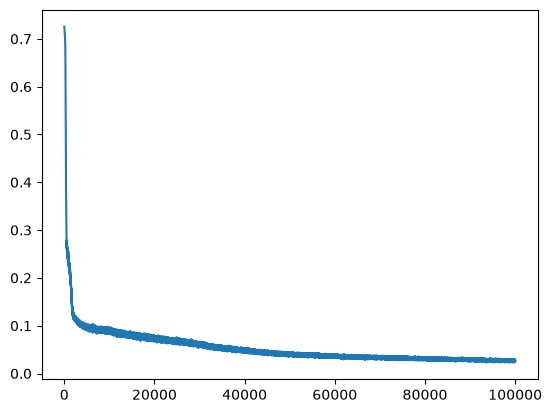

In [ ]:
hist_loss = train(
    env = env,
    opt = opt,
    game = 1000,
)

plt.plot(range(len(hist_loss)), hist_loss, label="loss")
print("End loss:", hist_loss[-1])

# Testing

In [218]:
acc = torch.round(test_encoder(enc, dec, data))[0].sum((1, 2))
print(f"Accuracy: {acc}")

Test:   0%|          | 0/1000 [00:00<?, ?it/s]

Accuracy: tensor([5., 1., 0., 1., 0., 1., 3., 0., 0., 0., 0., 0.], dtype=torch.float64)


# Save

In [ ]:
from torch.profiler import profile, ProfilerActivity

input = torch.rand(1, 1, 32)
plankton.cpu().eval()

with profile(activities=[ProfilerActivity.CPU], record_shapes=True) as prof:
    plankton(input)

print(prof.key_averages().table(sort_by="cpu_time_total"))

In [ ]:
#Save
input = torch.rand(5, 1, 32)
plankton.cpu().eval()
onnx_plankton = onnx.dynamo_export(plankton, input)
onnx_plankton.save("plankton.onnx")
print("succses")